# Python Foundations for Molecular Data #

## Objective:
- Identify and understand how Python can filter, compare, validate, and visualize amino-acid data.
- Learn to use foundations such as: Loops, Conditions, Functions, Sets, Sorting, Assertions, pandas, and Matplotlib.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
DATA_DIR = Path("Data")
RESULTS_DIR = Path("Results")

DATA_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Data directory:", DATA_DIR)
print("Results directory:", RESULTS_DIR)
print("Data directory exists:", DATA_DIR.exists())
print("Results directory exists:", RESULTS_DIR.exists())

Data directory: Data
Results directory: Results
Data directory exists: True
Results directory exists: True


## Representing amino-acid properties

Each amino acid will be represented as a Python dictionary containing:

- A three letter code
- A one letter code
- A broad chemical category
- Whether the side chain is aromatic
- An estimated side chain charge category

These categories will be used to simplify descriptions for introductory data analysis. Real amino-acid behavior depends on pH, protein environment, local molecular interaction, and other variables. 

In [3]:
amino_acids= [{"three_letter": "ASP" , "one_letter": "D" , "category": "Acidic" , "aromatic": False , "charge": "Negative"} ,
             {"three_letter": "GLU" , "one_letter": "E" , "category": "Acidic" , "aromatic": False , "charge": "Negative"} ,
             {"three_letter": "ARG" , "one_letter": "R" , "category": "Basic" , "aromatic": False , "charge": "Positive"} ,
             {"three_letter": "ASN" , "one_letter": "N" , "category": "Polar uncharged" , "aromatic": False , "charge": "Neutral"} ,
             {"three_letter": "LEU" , "one_letter": "L" , "category": "Hydrophobic" , "aromatic": False , "charge": "Neutral"} ,
             {"three_letter": "VAL" , "one_letter": "V" , "category": "Hydrophobic" , "aromatic": False , "charge": "Neutral"} ,
             {"three_letter": "PHE" , "one_letter": "F" , "category": "Aromatic" , "aromatic": True , "charge": "Neutral"} ,
             {"three_letter": "TYR" , "one_letter": "Y" , "category": "Aromatic" , "aromatic": True , "charge": "Neutral"}]
print("Number of amino acid records:", len(amino_acids))

Number of amino acid records: 8


In [4]:
first_amino_acid = amino_acids[0]
print(first_amino_acid) 

{'three_letter': 'ASP', 'one_letter': 'D', 'category': 'Acidic', 'aromatic': False, 'charge': 'Negative'}


In [5]:
print("Three_letter_code:", first_amino_acid["three_letter"])
print("One_letter_code:", first_amino_acid["one_letter"])
print("Category:", first_amino_acid["category"])
print("Aromatic:", first_amino_acid["aromatic"])
print("Charge:", first_amino_acid["charge"])

Three_letter_code: ASP
One_letter_code: D
Category: Acidic
Aromatic: False
Charge: Negative


In [6]:
for amino_acid in amino_acids:
    print(amino_acid["three_letter"] , "| Category:" , amino_acid["category"], "| Charge:" , amino_acid["charge"])

ASP | Category: Acidic | Charge: Negative
GLU | Category: Acidic | Charge: Negative
ARG | Category: Basic | Charge: Positive
ASN | Category: Polar uncharged | Charge: Neutral
LEU | Category: Hydrophobic | Charge: Neutral
VAL | Category: Hydrophobic | Charge: Neutral
PHE | Category: Aromatic | Charge: Neutral
TYR | Category: Aromatic | Charge: Neutral


In [7]:
required_keys = {"three_letter", "one_letter" , "category" , "aromatic" , "charge"}
print("Required Keys:", required_keys) 


Required Keys: {'charge', 'one_letter', 'three_letter', 'aromatic', 'category'}


In [8]:
assert  len (amino_acids) > 0, "The amino-acid data set is empty"
for amino_acid in amino_acids:
    available_keys = set(amino_acid.keys())
    assert required_keys.issubset(available_keys), (f"Missing information in this record:{amino_acid}")
print ("Dataset validation passed")

Dataset validation passed


In [9]:
for amino_acid in amino_acids:
    assert isinstance(amino_acid["three_letter"], str), "The three-letter code must be text"
    assert isinstance(amino_acid["one_letter"], str), "The one-letter code must be text"
    assert isinstance(amino_acid["category"], str), "The category must be text"
    assert isinstance(amino_acid["aromatic"], bool), "The armoatic field must be True or False"
    assert isinstance(amino_acid["charge"], str), "The charge category must be text"
print("Data-type validation passed.")

Data-type validation passed.


In [10]:
for amino_acid in amino_acids:
    three_letter_code = amino_acid["three_letter"]
    one_letter_code = amino_acid["one_letter"]
    assert len(three_letter_code) == 3, (f"Invalid three-letter code:{three_letter_code}")
    assert len(one_letter_code) == 1, (f"Invalid one-letter code:{one_letter_code}")
print("Amino-acid code-length validation passed.")

Amino-acid code-length validation passed.


In [11]:
three_letter_codes = [amino_acid["three_letter"] for amino_acid in amino_acids]
print("Three-letter codes:", three_letter_codes)

Three-letter codes: ['ASP', 'GLU', 'ARG', 'ASN', 'LEU', 'VAL', 'PHE', 'TYR']


In [12]:
unique_three_letter_codes = set(three_letter_codes)
print("Total codes:",  len(three_letter_codes))
print("Unique codes:", len(unique_three_letter_codes))

assert len(three_letter_codes) == len(unique_three_letter_codes), "Duplicate amino-acid codes were found"
print("All amino-acid codes are unique")

Total codes: 8
Unique codes: 8
All amino-acid codes are unique


## Converting the molecular records into a table

The amino-acid data are currently stored as a list of dictionaries. This format is useful for practicing Python loops, conditions, and data structures.

A pandas DataFrame converts the records into a rectangular table that is easier to inspect, filter and save. 

In [13]:
amino_acid_table = pd.DataFrame(amino_acids)
amino_acid_table 

,three_letter,one_letter,category,aromatic,charge
0,ASP,D,Acidic,False,Negative
1,GLU,E,Acidic,False,Negative
2,ARG,R,Basic,False,Positive
3,ASN,N,Polar uncharged,False,Neutral
4,LEU,L,Hydrophobic,False,Neutral
5,VAL,V,Hydrophobic,False,Neutral
6,PHE,F,Aromatic,True,Neutral
7,TYR,Y,Aromatic,True,Neutral


In [14]:
print("Table shape:", amino_acid_table.shape)
print("Number of rows:", amino_acid_table.shape[0])
print("Number of columns:", amino_acid_table.shape[1])

Table shape: (8, 5)
Number of rows: 8
Number of columns: 5


In [15]:
column_names = amino_acid_table.columns.tolist()
print("Column names:", column_names)

Column names: ['three_letter', 'one_letter', 'category', 'aromatic', 'charge']


In [16]:
assert required_keys.issubset(set(column_names)), "The Dataframe is missing required columns"
print ("DataFrame column validation passed.") 

DataFrame column validation passed.


In [17]:
amino_acid_data_path=(DATA_DIR/"Amino_acid_properties.csv")
amino_acid_table.to_csv(amino_acid_data_path, index=False)
print("Data saved to:", amino_acid_data_path)
print("File exists:", amino_acid_data_path.exists())
print("File size:", amino_acid_data_path.stat().st_size, "bytes")

Data saved to: Data\Amino_acid_properties.csv
File exists: True
File size: 297 bytes


In [18]:
reloaded_amino_acid_table = pd.read_csv(amino_acid_data_path) 
reloaded_amino_acid_table

,three_letter,one_letter,category,aromatic,charge
0,ASP,D,Acidic,False,Negative
1,GLU,E,Acidic,False,Negative
2,ARG,R,Basic,False,Positive
3,ASN,N,Polar uncharged,False,Neutral
4,LEU,L,Hydrophobic,False,Neutral
5,VAL,V,Hydrophobic,False,Neutral
6,PHE,F,Aromatic,True,Neutral
7,TYR,Y,Aromatic,True,Neutral


In [19]:
assert(reloaded_amino_acid_table.shape == amino_acid_table.shape), "The reloaded table has different dimensions"
assert(reloaded_amino_acid_table.columns.tolist() == amino_acid_table.columns.tolist()), "The reloaded table has different columns"
print("The CSV was saved and reloaded successfully")

The CSV was saved and reloaded successfully


## Representing an example protein segment

The amino-acid property table describes amino-acid types, such as ASP, ARG, and TYR. A protein sequence can contain the same amino-acid type at several different positions.

In this section, each residue will be represented by:

- Its three letter amino acid code
- Its position in an example protein segment

The residue identities will then be connected to the amino-acid property dataset. 

In [20]:
example_residues = [{"residue_name": "ASP" , "residue_number": 12},
                    {"residue_name": "LEU" , "residue_number": 13},
                    {"residue_name": "TYR" , "residue_number": 14},
                    {"residue_name": "ARG" , "residue_number": 15},
                    {"residue_name": "ASN" , "residue_number": 16},
                    {"residue_name": "VAL" , "residue_number": 17},
                    {"residue_name": "PHE" , "residue_number": 18},
                    {"residue_name": "GLU" , "residue_number": 19},
                    {"residue_name": "LEU" , "residue_number": 20},
                    {"residue_name": "TYR" , "residue_number": 21}]
print("Number of example residues:", len(example_residues))

Number of example residues: 10


In [21]:
for residue in example_residues:
    print(residue["residue_name"], residue["residue_number"])

ASP 12
LEU 13
TYR 14
ARG 15
ASN 16
VAL 17
PHE 18
GLU 19
LEU 20
TYR 21


In [22]:
for residue in example_residues:
    residue_label = (f"{residue['residue_name']}" f"{residue['residue_number']}")
    print(residue_label) 

ASP12
LEU13
TYR14
ARG15
ASN16
VAL17
PHE18
GLU19
LEU20
TYR21


In [23]:
residue_labels = [f"{residue['residue_name']}{residue['residue_number']}"
                  for residue in example_residues]
print("Residue labels:", residue_labels)

Residue labels: ['ASP12', 'LEU13', 'TYR14', 'ARG15', 'ASN16', 'VAL17', 'PHE18', 'GLU19', 'LEU20', 'TYR21']


In [24]:
residue_required_keys = {"residue_name" , "residue_number"}
assert len(example_residues) > 0 , "The example residue dataset is empty"
for residue in example_residues:
    available_keys = set(residue.keys())
    assert residue_required_keys.issubset(available_keys), (f"Missing information in residue record: {residue}")
    assert isinstance(residue["residue_name"], str), "The residue name must be text"
    assert isinstance(residue["residue_number"], int), "The residue number must be a whole number"
print("Example residue validation passed")

Example residue validation passed


In [25]:
for residue in example_residues: 
    residue_name = residue["residue_name"]
    assert residue_name in unique_three_letter_codes, (f"{residue_name} is absent from the amino-acid dataset")
print("Every example residue has a matching amino-acid record")

Every example residue has a matching amino-acid record


In [26]:
amino_acid_lookup = {amino_acid["three_letter"]: amino_acid for amino_acid in amino_acids}
print(amino_acid_lookup)

{'ASP': {'three_letter': 'ASP', 'one_letter': 'D', 'category': 'Acidic', 'aromatic': False, 'charge': 'Negative'}, 'GLU': {'three_letter': 'GLU', 'one_letter': 'E', 'category': 'Acidic', 'aromatic': False, 'charge': 'Negative'}, 'ARG': {'three_letter': 'ARG', 'one_letter': 'R', 'category': 'Basic', 'aromatic': False, 'charge': 'Positive'}, 'ASN': {'three_letter': 'ASN', 'one_letter': 'N', 'category': 'Polar uncharged', 'aromatic': False, 'charge': 'Neutral'}, 'LEU': {'three_letter': 'LEU', 'one_letter': 'L', 'category': 'Hydrophobic', 'aromatic': False, 'charge': 'Neutral'}, 'VAL': {'three_letter': 'VAL', 'one_letter': 'V', 'category': 'Hydrophobic', 'aromatic': False, 'charge': 'Neutral'}, 'PHE': {'three_letter': 'PHE', 'one_letter': 'F', 'category': 'Aromatic', 'aromatic': True, 'charge': 'Neutral'}, 'TYR': {'three_letter': 'TYR', 'one_letter': 'Y', 'category': 'Aromatic', 'aromatic': True, 'charge': 'Neutral'}}


In [27]:
asp_properties = amino_acid_lookup["ASP"]
print("ASP properties:", asp_properties)

ASP properties: {'three_letter': 'ASP', 'one_letter': 'D', 'category': 'Acidic', 'aromatic': False, 'charge': 'Negative'}


In [28]:
print("ASP category:" , asp_properties["category"])
print("ASP charge:" , asp_properties["charge"])
print("ASP aromatic:" , asp_properties["aromatic"])

ASP category: Acidic
ASP charge: Negative
ASP aromatic: False


In [29]:
annotated_residues = []
for residue in example_residues:
    residue_name = residue["residue_name"]
    residue_number = residue["residue_number"]
    properties = amino_acid_lookup[residue_name]
    annotated_record = {"residue_name": residue_name, "residue_number": residue_number, "residue_label": f"{residue_name} {residue_number}" , "category": properties["category"], "aromatic": properties["aromatic"], "charge":properties["charge"]}
    annotated_residues.append(annotated_record)
print("Number of annotated residues:", len(annotated_residues))

Number of annotated residues: 10


In [30]:
for residue in annotated_residues:
    print(residue["residue_label"], "| Category:", residue["category"], "| Charge:", residue["charge"], "| Aromatic:", residue["aromatic"])

ASP 12 | Category: Acidic | Charge: Negative | Aromatic: False
LEU 13 | Category: Hydrophobic | Charge: Neutral | Aromatic: False
TYR 14 | Category: Aromatic | Charge: Neutral | Aromatic: True
ARG 15 | Category: Basic | Charge: Positive | Aromatic: False
ASN 16 | Category: Polar uncharged | Charge: Neutral | Aromatic: False
VAL 17 | Category: Hydrophobic | Charge: Neutral | Aromatic: False
PHE 18 | Category: Aromatic | Charge: Neutral | Aromatic: True
GLU 19 | Category: Acidic | Charge: Negative | Aromatic: False
LEU 20 | Category: Hydrophobic | Charge: Neutral | Aromatic: False
TYR 21 | Category: Aromatic | Charge: Neutral | Aromatic: True


## Annotating example protein residues

Each numbered residue is matched to the amino-acid property dataset using its three letter code.

The resulting table contains both positonal information and broad chemical properties. 

In [31]:
annotated_residue_table = pd.DataFrame(annotated_residues)
annotated_residue_table

,residue_name,residue_number,residue_label,category,aromatic,charge
0,ASP,12,ASP 12,Acidic,False,Negative
1,LEU,13,LEU 13,Hydrophobic,False,Neutral
2,TYR,14,TYR 14,Aromatic,True,Neutral
3,ARG,15,ARG 15,Basic,False,Positive
4,ASN,16,ASN 16,Polar uncharged,False,Neutral
5,VAL,17,VAL 17,Hydrophobic,False,Neutral
6,PHE,18,PHE 18,Aromatic,True,Neutral
7,GLU,19,GLU 19,Acidic,False,Negative
8,LEU,20,LEU 20,Hydrophobic,False,Neutral
9,TYR,21,TYR 21,Aromatic,True,Neutral


In [32]:
assert len(annotated_residues) == len(example_residues)
assert annotated_residue_table["category"]. notna().all()
assert annotated_residue_table["charge"]. notna().all()
print("Annotated residue validation passed.")

Annotated residue validation passed.


## Filtering residues by molecular properties

A molecular dataset often contains more records than are relevant to a specific question. Filtering allows us to retain only records that satisfy a defined criterion.

We will identify example residues classified as acidic, then convert the same logic into a reusable function.

In [33]:
acidic_residues = []
for residue in annotated_residues:
    if residue["category"] == "Acidic":
        acidic_residues.append(residue)
print("Number of acidic residues:", len(acidic_residues))

Number of acidic residues: 2


In [34]:
for residue in acidic_residues:
    print(residue["residue_label"], "| Category:", residue["category"], "| Charge:", residue ["charge"])

ASP 12 | Category: Acidic | Charge: Negative
GLU 19 | Category: Acidic | Charge: Negative


In [35]:
assert len (acidic_residues) > 0
for residue in acidic_residues:
    assert residue["category"] == "Acidic", (f"{residue['residue_label']} was incorrectly classified")
print("Acidic residue selection passed validation")

Acidic residue selection passed validation


In [36]:
def select_residues_by_category(residue_records, selected_category):
    selected_residue = []
    for residue in residue_records:
        if residue["category"] == selected_category:
            selected_residue.append(residue)
    return selected_residue

In [37]:
acidic_residues_function = select_residues_by_category(annotated_residues, "Acidic")
print("Acidic residues selected by the function:", len(acidic_residues_function))

Acidic residues selected by the function: 2


In [38]:
hydrophobic_residues = select_residues_by_category(annotated_residues, "Hydrophobic")
hydrophobic_labels = [residue["residue_label"] for residue in hydrophobic_residues]
print ("Hydrophobic residues:", hydrophobic_labels)

Hydrophobic residues: ['LEU 13', 'VAL 17', 'LEU 20']


In [39]:
basic_residues = select_residues_by_category(annotated_residues, "Basic")
basic_labels = [residue["residue_label"] for residue in basic_residues]
print ("Basic residues:", basic_labels)

Basic residues: ['ARG 15']


In [40]:
aromatic_residues = [residue for residue in annotated_residues if residue ["aromatic"] is True]
aromatic_labels = [residue["residue_label"] for residue in aromatic_residues]
print("Aromatic residues:", aromatic_labels)

Aromatic residues: ['TYR 14', 'PHE 18', 'TYR 21']


In [41]:
def select_residues_by_charge(residue_records, selected_charge):
    selected_residues = []

    for residue in residue_records:
        if residue["charge"] == selected_charge: selected_residues.append(residue)

    return selected_residues

In [42]:
negative_residues = select_residues_by_charge(annotated_residues, "Negative")
negative_labels = [residue["residue_label"] for residue in negative_residues]
print("Negative residues:", negative_labels)

Negative residues: ['ASP 12', 'GLU 19']


In [43]:
positive_residues = select_residues_by_charge(annotated_residues, "Positive")
positive_labels = [residue["residue_label"] for residue in positive_residues]
print("Positive residues:", positive_labels)

Positive residues: ['ARG 15']


In [44]:
charged_residues = [residue for residue in annotated_residues if residue["charge"] == "Positive" or residue["charge"] == "Negative"]
charged_labels = [residue["residue_label"] for residue in charged_residues]
print("Charged residues:", charged_labels)

Charged residues: ['ASP 12', 'ARG 15', 'GLU 19']


In [45]:
selected_range_residues = [residue for residue in annotated_residues if 14 <= residue["residue_number"] <= 18]
selected_range_labels = [residue["residue_label"] for residue in selected_range_residues]
print("Residues numbered 14 through 18:", selected_range_labels)

Residues numbered 14 through 18: ['TYR 14', 'ARG 15', 'ASN 16', 'VAL 17', 'PHE 18']


In [46]:
def select_residues_by_number_range(residue_records, first_number, last_number):
    selected_residues = [] 
    for residue in residue_records:
        residue_number = residue["residue_number"] 
        if first_number <= residue_number <= last_number:
            selected_residues.append(residue)
    return selected_residues

In [47]:
range_test = select_residues_by_number_range(annotated_residues, 14, 18)
range_test_labels = [residue["residue_label"] for residue in range_test]
print("Range selected by the function:", range_test_labels)

Range selected by the function: ['TYR 14', 'ARG 15', 'ASN 16', 'VAL 17', 'PHE 18']


## Comparing two example residue groups

Two synthetic residue groups will be compared to identify:

- Residues found in both groups
- Residues found only in Group A
- Residues found only in Group B
- All residues found in either group

These groups will act as examples rather than results from real experiments. 

In [48]:
group_a_labels = {"ASP12", "TYR14", "ARG15", "ASN16", "PHE18"}
group_b_labels = {"TYR14", "ASN16", "VAL17", "PHE18", "GLU19"}
print("Group A:", group_a_labels)
print()
print("Group B:", group_b_labels)

Group A: {'ARG15', 'ASP12', 'TYR14', 'PHE18', 'ASN16'}

Group B: {'VAL17', 'TYR14', 'PHE18', 'GLU19', 'ASN16'}


In [49]:
shared_labels = group_a_labels & group_b_labels
print("Residues shared by Group A and Group B:", shared_labels)

Residues shared by Group A and Group B: {'TYR14', 'PHE18', 'ASN16'}


In [50]:
group_a_only_labels = group_a_labels - group_b_labels
print("Residues found only in Group A:", group_a_only_labels)

Residues found only in Group A: {'ARG15', 'ASP12'}


In [51]:
group_b_only_labels = group_b_labels - group_a_labels
print("Residues found only in Group B:", group_b_only_labels)

Residues found only in Group B: {'GLU19', 'VAL17'}


In [52]:
all_group_labels = group_a_labels | group_b_labels
print("All residues found in either group:" , all_group_labels)

All residues found in either group: {'VAL17', 'ARG15', 'TYR14', 'ASP12', 'PHE18', 'GLU19', 'ASN16'}


In [53]:
print("SET COMPARISON SUMMARY")
print("----------------------")
print("Group A total:", len(group_a_labels))
print("Group B total:", len(group_b_labels))
print("Shared:", len(shared_labels))
print("Group A only:", len(group_a_only_labels))
print("Group B only:", len(group_b_only_labels))
print("All unique residues:", len(all_group_labels))

SET COMPARISON SUMMARY
----------------------
Group A total: 5
Group B total: 5
Shared: 3
Group A only: 2
Group B only: 2
All unique residues: 7


In [54]:
assert len(shared_labels) + len(group_a_only_labels) == len(group_a_labels), "Group A categories do not add up correctly"
assert len(shared_labels) + len(group_b_only_labels) == len(group_b_labels), "Group B categories do not add up correctly"
assert len(shared_labels) + len(group_a_only_labels) + len(group_b_only_labels) == len(all_group_labels), "The union categories do not add up correctly"
print("Set-comparison validation passed.")

Set-comparison validation passed.


In [55]:
def residue_number_from_label(residue_label):
    return int(residue_label[3:])

In [56]:
print(residue_number_from_label("ASP12"))
print(residue_number_from_label("GLU19"))

12
19


In [57]:
shared_labels_sorted = sorted(shared_labels, key=residue_number_from_label)
group_a_only_sorted = sorted(group_a_only_labels, key=residue_number_from_label)
group_b_only_sorted = sorted(group_b_only_labels, key=residue_number_from_label)
all_group_labels_sorted = sorted(all_group_labels, key=residue_number_from_label)

In [58]:
print("Shared residues:", shared_labels_sorted)
print("Group A only:", group_a_only_sorted)
print("Group B only:", group_b_only_sorted)
print("All residues:", all_group_labels_sorted)

Shared residues: ['TYR14', 'ASN16', 'PHE18']
Group A only: ['ASP12', 'ARG15']
Group B only: ['VAL17', 'GLU19']
All residues: ['ASP12', 'TYR14', 'ARG15', 'ASN16', 'VAL17', 'PHE18', 'GLU19']


## Building a residue-group comparison table

The set comparison identifies shared and group specific residues. The results will now be converted into a table containing one row for every unique residue.

The table will record whether each residue belongs to Group A, Group B, or both.

In [59]:
comparison_rows = []

for residue_label in all_group_labels_sorted:
    in_group_a = residue_label in group_a_labels
    in_group_b = residue_label in group_b_labels
    if in_group_a and in_group_b:
        comparison_category = "Shared"
    elif in_group_a:
        comparison_category = "Group A only"
    else:
        comparison_category = "Group B only"
    comparison_row = {"residue_label": residue_label, "residue_number": residue_number_from_label (residue_label), "in_group_a": in_group_a, "in_group_b": in_group_b, "comparison_category": comparison_category}
    comparison_rows.append(comparison_row)
print("Comparison rows created:", len(comparison_rows))

Comparison rows created: 7


In [60]:
comparison_table = pd.DataFrame(comparison_rows)
comparison_table

,residue_label,residue_number,in_group_a,in_group_b,comparison_category
0,ASP12,12,True,False,Group A only
1,TYR14,14,True,True,Shared
2,ARG15,15,True,False,Group A only
3,ASN16,16,True,True,Shared
4,VAL17,17,False,True,Group B only
5,PHE18,18,True,True,Shared
6,GLU19,19,False,True,Group B only


In [61]:
assert len(comparison_table) == len(all_group_labels), ("The table does not contain every unique residue")
assert comparison_table["residue_label"].is_unique, ("The comparison table contains duplicate residue labels")
assert comparison_table["comparison_category"].notna().all(), ("At least one residue is missing a comparison category")
print("Comparison-table validation passed.")

Comparison-table validation passed.


In [62]:
comparison_table_path = (RESULTS_DIR / "Example_Residue_Group_Comparison.csv")
comparison_table.to_csv(comparison_table_path, index=False)
print("Comparison table saved to:", comparison_table_path)
print("File exists:", comparison_table_path.exists())
print("File size:", comparison_table_path.stat().st_size, "bytes")

Comparison table saved to: Results\Example_Residue_Group_Comparison.csv
File exists: True
File size: 289 bytes


In [63]:
category_counts = (annotated_residue_table["category"].value_counts().rename_axis("category").reset_index(name="residue_count"))
category_counts

,category,residue_count
0,Hydrophobic,3
1,Aromatic,3
2,Acidic,2
3,Basic,1
4,Polar uncharged,1


In [64]:
assert category_counts["residue_count"].sum() == len(annotated_residue_table), "Category counts do not equal the number of residues"
print("Category-count validation passed.")

Category-count validation passed.


In [65]:
category_counts_path = (RESULTS_DIR / "Amino_Acid_Category_Counts.csv")
category_counts.to_csv(category_counts_path, index=False)
print("Category counts saved to:", category_counts_path) 

Category counts saved to: Results\Amino_Acid_Category_Counts.csv


In [66]:
category_order = ["Acidic", "Basic", "Polar uncharged", "Hydrophobic", "Aromatic"]
category_counts_ordered = (category_counts.set_index("category").reindex(category_order).reset_index())
category_counts_ordered

,category,residue_count
0,Acidic,2
1,Basic,1
2,Polar uncharged,1
3,Hydrophobic,3
4,Aromatic,3


In [67]:
assert category_counts_ordered["residue_count"].notna().all(), "At least one category is missing from the example segment"
print("All expected categories are present.")

All expected categories are present.


In [68]:
category_colors = {"Acidic": "#D55E00", "Basic": "#0072B2", "Polar uncharged": "#CC79A7", "Hydrophobic": "#009E73", "Aromatic": "#E69F00"}
bar_colors = [category_colors[category] for category in category_counts_ordered["category"]]

## Visualizing the example protein segment

The first figure shows the number of residues assigned to each amino-acid category in the synthetic protein segment.

The chart is a descriptive summary of the example data. It does not represent the composition of a real protein.

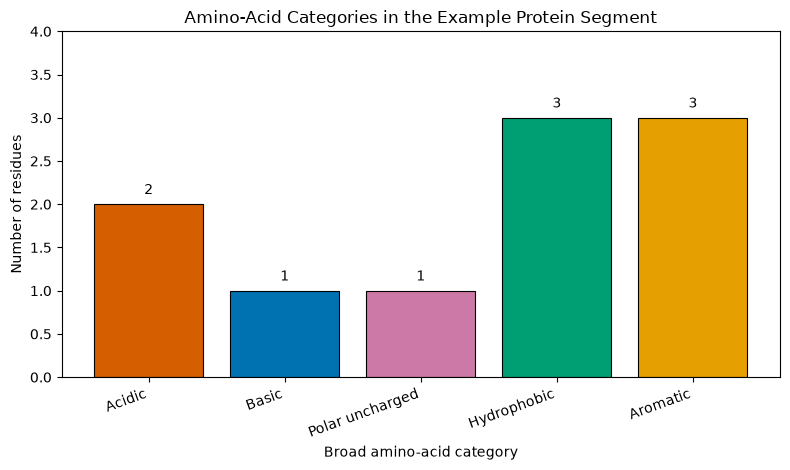

In [69]:
fig, ax = plt.subplots(figsize=(8, 4.8))

bars = ax.bar(category_counts_ordered["category"], category_counts_ordered["residue_count"], color=bar_colors, edgecolor="black", linewidth=0.8)

ax.set_title("Amino-Acid Categories in the Example Protein Segment")
ax.set_xlabel("Broad amino-acid category")
ax.set_ylabel("Number of residues")
ax.set_ylim(0, category_counts_ordered["residue_count"].max() + 1)

for bar, count in zip(bars, category_counts_ordered["residue_count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08, str(count), ha="center", va="bottom")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [70]:
category_figure_path = (RESULTS_DIR / "Amino_Acid_Category_Counts.png")
fig.savefig(category_figure_path, dpi=150, bbox_inches="tight")
print("Category chart saved to:", category_figure_path)

Category chart saved to: Results\Amino_Acid_Category_Counts.png


In [71]:
group_comparison_summary = pd.DataFrame({"comparison_category": ["Shared","Group A only", "Group B only"], "residue_count": [len(shared_labels), len(group_a_only_labels), len(group_b_only_labels)]})
group_comparison_summary

,comparison_category,residue_count
0,Shared,3
1,Group A only,2
2,Group B only,2


In [72]:
assert (group_comparison_summary["residue_count"].sum() == len(all_group_labels)), "The comparison counts do not equal the union size"
assert len(group_comparison_summary) == 3, "The comparison summary should have three categories"
print("Group-comparison summary passed") 

Group-comparison summary passed


## Visualizing the synthetic residue-group comparison

The second figure summarizes the overlap between the two synthetic residue groups.

- Shared residues appear in both groups.
- Group A-only residues appear only in Group A.
- Group B-only residues appear only in Group B.

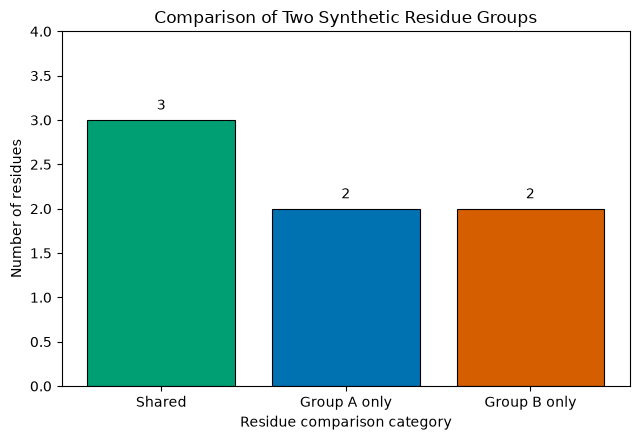

In [73]:
comparison_colors = ["#009E73", "#0072B2", "#D55E00"]
fig, ax = plt.subplots(figsize=(6.5, 4.5))
bars = ax.bar(group_comparison_summary["comparison_category"], group_comparison_summary["residue_count"], color=comparison_colors, edgecolor="black", linewidth=0.8)

ax.set_title("Comparison of Two Synthetic Residue Groups")
ax.set_xlabel("Residue comparison category")
ax.set_ylabel("Number of residues")
ax.set_ylim(0, group_comparison_summary["residue_count"].max() + 1)

for bar, count in zip(bars, group_comparison_summary["residue_count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.08, str(count), ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [74]:
group_summary_path = (RESULTS_DIR / "Example_Residue_Group_Summary.csv")
group_comparison_summary.to_csv(group_summary_path, index=False)
print("Group summary saved to:", group_summary_path)

Group summary saved to: Results\Example_Residue_Group_Summary.csv


## Interpretation

This project demonstrated how Python can represent and analyze simplified molecular data.

The amino-acid dataset was stored as a list of dictionaries. Each dictionary contained a three-letter code, a one-letter code, a broad chemical category, an aromaticity indicator, and a simplified charge category.

A synthetic protein segment was then represented as a collection of numbered residues. Each residue was matched to the amino-acid property dataset using its three-letter code. This produced an annotated table containing both residue positions and broad chemical properties.

Conditional filters were used to identify acidic, basic, hydrophobic, aromatic, charged, and position-specific residues. 

Two synthetic residue groups were compared using set operations. The intersection identified residues found in both groups, while set differences identified residues specific to each group. The union identified every unique residue found in either group.

## Conclusion

This project established Python skills for working with molecular data.

This analysis used a variety of tools such as lists, dictionaries, loops, conditional statements, and functions to organize amino-acid properties, annotate numbered residues, filter records using explicit criteria, and compare residue groups. 